In [85]:
# 아래의 펭귄데이터가 있다.
# KNN 과 결정트리 모델을 사용 하여.
# 평가지표를 비교 하시오.

# 조건 : 전처리 및 정규화 과정을 거치시오.


# ==============================
# 📦 1. 라이브러리 로드
# ==============================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ==============================
# 🐧 2. 데이터 로드
# ==============================
df = sns.load_dataset("penguins")

print(df.head())
print(df.info())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  

In [86]:
display(df[df["bill_depth_mm"].isnull()])

# species, island를 제외하고 모두 다 null값을 가진 것이므로 2개 제외 판단


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


In [87]:
df = df.drop(index=[3, 339])

In [88]:
# 엑셀 저장
df.to_excel("penguin.xlsx",index=False)

In [89]:
# 전처리
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["species"] = le.fit_transform(df['species'])
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,0,Torgersen,39.1,18.7,181.0,3750.0,Male
1,0,Torgersen,39.5,17.4,186.0,3800.0,Female
2,0,Torgersen,40.3,18.0,195.0,3250.0,Female
4,0,Torgersen,36.7,19.3,193.0,3450.0,Female
5,0,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,2,Biscoe,47.2,13.7,214.0,4925.0,Female
340,2,Biscoe,46.8,14.3,215.0,4850.0,Female
341,2,Biscoe,50.4,15.7,222.0,5750.0,Male
342,2,Biscoe,45.2,14.8,212.0,5200.0,Female


In [90]:
df.isnull().sum()


species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  9
dtype: int64

In [91]:
df['sex'] = df['sex'].mode()[0]

print(df)


     species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0          0  Torgersen            39.1           18.7              181.0   
1          0  Torgersen            39.5           17.4              186.0   
2          0  Torgersen            40.3           18.0              195.0   
4          0  Torgersen            36.7           19.3              193.0   
5          0  Torgersen            39.3           20.6              190.0   
..       ...        ...             ...            ...                ...   
338        2     Biscoe            47.2           13.7              214.0   
340        2     Biscoe            46.8           14.3              215.0   
341        2     Biscoe            50.4           15.7              222.0   
342        2     Biscoe            45.2           14.8              212.0   
343        2     Biscoe            49.9           16.1              213.0   

     body_mass_g   sex  
0         3750.0  Male  
1         3800.0  Male  


In [92]:
le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])

In [93]:
le_island = LabelEncoder()
df['island'] = le_island.fit_transform(df['island'])

print(df)

     species  island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0          0       2            39.1           18.7              181.0   
1          0       2            39.5           17.4              186.0   
2          0       2            40.3           18.0              195.0   
4          0       2            36.7           19.3              193.0   
5          0       2            39.3           20.6              190.0   
..       ...     ...             ...            ...                ...   
338        2       0            47.2           13.7              214.0   
340        2       0            46.8           14.3              215.0   
341        2       0            50.4           15.7              222.0   
342        2       0            45.2           14.8              212.0   
343        2       0            49.9           16.1              213.0   

     body_mass_g  sex  
0         3750.0    0  
1         3800.0    0  
2         3250.0    0  
4         3450.

In [94]:
X = df.drop(columns=['species'])

y = df['species']



X_train, X_test, y_train, y_test = train_test_split(
    X, y,

    test_size=0.2,

    random_state=42
)



scaler = StandardScaler()



X_train = scaler.fit_transform(X_train)

print(X_train)



X_test = scaler.transform(X_test)

print(X_test)

[[-0.90602883 -0.24041066  0.60354716 -0.37926138 -0.18011949  0.        ]
 [ 1.93702715 -1.79533121  0.50249327 -0.59143014 -0.93372288  0.        ]
 [ 0.51549916 -1.27099754 -0.30593789 -1.1572135  -1.0279233   0.        ]
 ...
 [-0.90602883 -1.05403188  1.46250527 -0.8035989  -0.39992048  0.        ]
 [-0.90602883  0.80825668 -1.51858463  1.31808871  1.35848743  0.        ]
 [-0.90602883 -1.12635376  1.46250527 -0.8035989   0.0396815   0.        ]]
[[-0.90602883  0.39240584 -1.31647684  0.54013659  0.7304846   0.        ]
 [ 1.93702715 -1.21675612  1.71514    -0.16709261 -0.55692118  0.        ]
 [-0.90602883 -0.80090528  1.8161939  -0.73287598 -0.39992048  0.        ]
 [ 0.51549916  0.01271594  1.31092442 -0.37926138  0.22808234  0.        ]
 [ 1.93702715 -0.45737632  0.60354716 -0.4499843   0.10248178  0.        ]
 [-0.90602883 -0.04152548 -1.61963852  0.46941367  0.10248178  0.        ]
 [ 0.51549916  1.83884355  1.86672084 -0.02564677  0.10248178  0.        ]
 [ 0.51549916  0.42

In [95]:
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train,y_train)

# 예측

pred = model.predict(X_test)
print(accuracy_score(y_test,pred))

1.0


결정트리 정확도(Accuracy): {accuracy_score(y_test, dt_pred):.4f}

[상세 분류 리포트]
              precision    recall  f1-score   support

      Adelie       1.00      0.94      0.97        35
   Chinstrap       0.86      1.00      0.92        12
      Gentoo       1.00      1.00      1.00        22

    accuracy                           0.97        69
   macro avg       0.95      0.98      0.96        69
weighted avg       0.98      0.97      0.97        69



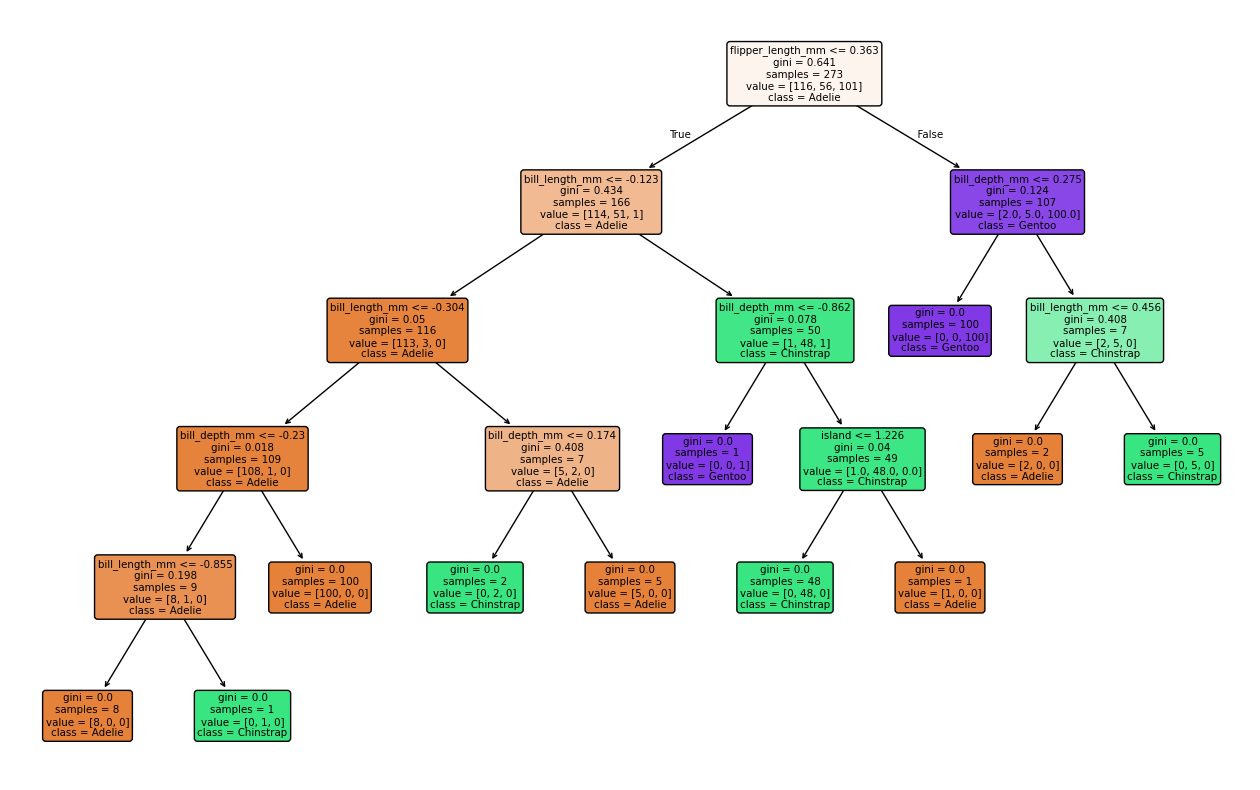

In [99]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
print("결정트리 정확도(Accuracy): {accuracy_score(y_test, dt_pred):.4f}")
print("\n[상세 분류 리포트]")

print(classification_report(y_test, dt_pred, target_names=le.classes_))

plt.figure(figsize=(16, 10))  
plot_tree(
    dt_model,                                   
    feature_names=df.drop(columns=['species']).columns.tolist(), 
    class_names=le.classes_.tolist(),            
    filled=True,                                 
    rounded=True                                 
)
plt.show()
